===== DATASET =====
[[2.49671415 1.8617357 ]
 [2.64768854 3.52302986]
 [1.76584663 1.76586304]
 [3.57921282 2.76743473]
 [1.53052561 2.54256004]
 [1.53658231 1.53427025]
 [2.24196227 0.08671976]
 [0.27508217 1.43771247]
 [0.98716888 2.31424733]
 [1.09197592 0.5876963 ]]

===== LABELS =====
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  0  1  1 -1  1  1 -1  0]


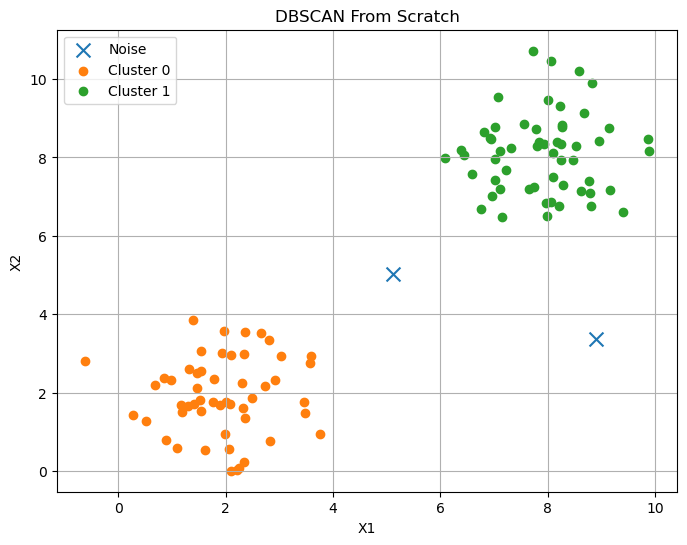

In [1]:
# ==========================================================
# DBSCAN FROM SCRATCH EN PYTHON
# ==========================================================
#
# DBSCAN signifie :
#
# Density-Based Spatial Clustering
# of Applications with Noise
#
# ----------------------------------------------------------
# TYPE D'APPRENTISSAGE :
# ----------------------------------------------------------
#
# Machine Learning non supervisé.
#
# Cela signifie :
#
# -> pas de variable cible y
# -> pas de classes connues
#
# L'algorithme doit découvrir
# les groupes automatiquement.
#
# ----------------------------------------------------------
# OBJECTIF DE DBSCAN :
# ----------------------------------------------------------
#
# ✔ regrouper les points proches
# ✔ détecter les clusters
# ✔ détecter les points bruités
#
# ----------------------------------------------------------
# AVANTAGES DE DBSCAN :
# ----------------------------------------------------------
#
# ✔ pas besoin choisir nombre clusters
# ✔ détecte bruit automatiquement
# ✔ fonctionne avec formes complexes
#
# ----------------------------------------------------------
# IDÉE PRINCIPALE :
# ----------------------------------------------------------
#
# Si plusieurs points sont proches,
# alors ils appartiennent au même cluster.
#
# ----------------------------------------------------------
# PARAMÈTRES IMPORTANTS :
# ----------------------------------------------------------
#
# eps :
# distance maximale entre voisins
#
# min_samples :
# nombre minimum voisins
# pour former un cluster
#
# ----------------------------------------------------------
# TYPES DE POINTS :
# ----------------------------------------------------------
#
# 1. Core Point
# -> beaucoup voisins
#
# 2. Border Point
# -> proche cluster
#
# 3. Noise Point
# -> isolé
#
# ==========================================================

# ==========================================================
# IMPORTATION DES LIBRARIES
# ==========================================================

# numpy :
# utilisé pour calculs mathématiques
import numpy as np

# matplotlib :
# utilisé pour affichage graphique
import matplotlib.pyplot as plt

# ==========================================================
# 1. DATASET
# ==========================================================

# ----------------------------------------------------------
# seed :
# garantit mêmes résultats aléatoires
# ----------------------------------------------------------

np.random.seed(42)

# ==========================================================
# CLUSTER 1
# ==========================================================
#
# np.random.randn(50, 2)
#
# -> 50 points
# -> 2 dimensions
#
# + [2,2]
#
# -> déplacer cluster vers position (2,2)
#
# ==========================================================

cluster1 = np.random.randn(50, 2) + [2, 2]

# ==========================================================
# CLUSTER 2
# ==========================================================
#
# deuxième groupe de points
#
# déplacé vers position (8,8)
#
# ==========================================================

cluster2 = np.random.randn(50, 2) + [8, 8]

# ==========================================================
# BRUIT (NOISE)
# ==========================================================
#
# Points aléatoires dispersés.
#
# DBSCAN doit détecter :
#
# -> ces points ne font partie
#    d'aucun cluster
#
# ==========================================================

noise = np.random.uniform(

    low=0,

    high=10,

    size=(10, 2)
)

# ==========================================================
# DATASET FINAL
# ==========================================================
#
# vstack :
# fusion verticale des données
#
# Dataset final contient :
#
# ✔ cluster1
# ✔ cluster2
# ✔ bruit
#
# ==========================================================

X = np.vstack((

    cluster1,

    cluster2,

    noise
))

# ----------------------------------------------------------
# Affichage premières lignes
# ----------------------------------------------------------

print("===== DATASET =====")

print(X[:10])

# ==========================================================
# 2. DISTANCE EUCLIDIENNE
# ==========================================================

def euclidean_distance(p1, p2):

    """
    ------------------------------------------------------
    DISTANCE EUCLIDIENNE
    ------------------------------------------------------

    Distance classique entre deux points.

    Exemple :

    p1 = (1,2)
    p2 = (4,6)

    ------------------------------------------------------
    FORMULE :
    ------------------------------------------------------

    distance =
    √((x2-x1)^2 + (y2-y1)^2)

    ------------------------------------------------------
    PLUS DISTANCE EST PETITE :
    ------------------------------------------------------

    -> points proches

    PLUS DISTANCE EST GRANDE :
    ------------------------------------------------------

    -> points éloignés
    """

    # ------------------------------------------------------
    # Calcul distance euclidienne
    # ------------------------------------------------------

    return np.sqrt(

        np.sum((p1 - p2) ** 2)
    )

# ==========================================================
# 3. TROUVER VOISINS
# ==========================================================

def find_neighbors(X, point_idx, eps):

    """
    ------------------------------------------------------
    Cette fonction cherche
    tous les voisins d'un point.
    ------------------------------------------------------

    Un voisin :
    distance <= eps

    ------------------------------------------------------
    PARAMÈTRES :
    ------------------------------------------------------

    X :
    dataset complet

    point_idx :
    index du point étudié

    eps :
    rayon maximal
    """

    # ------------------------------------------------------
    # Liste des voisins
    # ------------------------------------------------------

    neighbors = []

    # ------------------------------------------------------
    # Parcourir tous les points
    # ------------------------------------------------------

    for i in range(len(X)):

        # --------------------------------------------------
        # Distance entre :
        #
        # point étudié
        # et
        # point i
        # --------------------------------------------------

        distance = euclidean_distance(

            X[point_idx],

            X[i]
        )

        # --------------------------------------------------
        # Si distance <= eps
        # alors voisin
        # --------------------------------------------------

        if distance <= eps:

            neighbors.append(i)

    # ------------------------------------------------------
    # Retourner voisins
    # ------------------------------------------------------

    return neighbors

# ==========================================================
# 4. DBSCAN
# ==========================================================

class DBSCAN:

    """
    ------------------------------------------------------
    Classe principale DBSCAN.
    ------------------------------------------------------

    Elle gère :

    ✔ recherche voisins
    ✔ création clusters
    ✔ détection bruit
    """

    def __init__(self,

                 eps=1.5,

                 min_samples=4):

        # --------------------------------------------------
        # eps :
        # rayon voisinage
        # --------------------------------------------------

        self.eps = eps

        # --------------------------------------------------
        # min_samples :
        # minimum voisins
        # pour créer cluster
        # --------------------------------------------------

        self.min_samples = min_samples

    # ======================================================
    # ENTRAINEMENT
    # ======================================================

    def fit(self, X):

        """
        --------------------------------------------------
        Fonction principale entraînement.
        --------------------------------------------------

        Étapes :

        1. parcourir points
        2. trouver voisins
        3. créer clusters
        4. détecter bruit
        """

        # --------------------------------------------------
        # Sauvegarder dataset
        # --------------------------------------------------

        self.X = X

        # --------------------------------------------------
        # Labels clusters
        # ------------------------------------------------------
        #
        # Initialement :
        #
        # -1 = bruit
        #
        # --------------------------------------------------

        self.labels = np.full(

            len(X),

            -1
        )

        # --------------------------------------------------
        # Tableau points visités
        # ------------------------------------------------------

        visited = np.full(

            len(X),

            False
        )

        # --------------------------------------------------
        # ID cluster actuel
        # ------------------------------------------------------

        cluster_id = 0

        # ==================================================
        # PARCOURIR TOUS LES POINTS
        # ==================================================

        for point_idx in range(len(X)):

            # ------------------------------------------------
            # Si déjà visité
            # ------------------------------------------------

            if visited[point_idx]:

                continue

            # ------------------------------------------------
            # Marquer comme visité
            # ------------------------------------------------

            visited[point_idx] = True

            # ------------------------------------------------
            # Trouver voisins
            # ------------------------------------------------

            neighbors = find_neighbors(

                X,

                point_idx,

                self.eps
            )

            # =================================================
            # POINT BRUIT
            # =================================================
            #
            # Pas assez voisins
            #
            # =================================================

            if len(neighbors) < self.min_samples:

                self.labels[point_idx] = -1

            # =================================================
            # NOUVEAU CLUSTER
            # =================================================

            else:

                self.expand_cluster(

                    point_idx,

                    neighbors,

                    cluster_id,

                    visited
                )

                # ------------------------------------------------
                # Passer cluster suivant
                # ------------------------------------------------

                cluster_id += 1

    # ======================================================
    # EXPANSION CLUSTER
    # ======================================================

    def expand_cluster(self,

                       point_idx,

                       neighbors,

                       cluster_id,

                       visited):

        """
        --------------------------------------------------
        Cette fonction agrandit
        un cluster.
        --------------------------------------------------

        Si un voisin possède
        beaucoup voisins :
        -> cluster continue grandir
        """

        # --------------------------------------------------
        # Attribuer cluster au point
        # ------------------------------------------------------

        self.labels[point_idx] = cluster_id

        # --------------------------------------------------
        # Index parcours voisins
        # ------------------------------------------------------

        i = 0

        # ==================================================
        # PARCOURIR VOISINS
        # ==================================================

        while i < len(neighbors):

            # ------------------------------------------------
            # Récupérer voisin actuel
            # ------------------------------------------------

            neighbor_idx = neighbors[i]

            # =================================================
            # SI PAS VISITÉ
            # =================================================

            if not visited[neighbor_idx]:

                # --------------------------------------------
                # Marquer visité
                # --------------------------------------------

                visited[neighbor_idx] = True

                # --------------------------------------------
                # Trouver voisins du voisin
                # --------------------------------------------

                new_neighbors = find_neighbors(

                    self.X,

                    neighbor_idx,

                    self.eps
                )

                # =================================================
                # SI CORE POINT
                # =================================================
                #
                # beaucoup voisins
                #
                # =================================================

                if len(new_neighbors) >= self.min_samples:

                    # --------------------------------------------
                    # Ajouter nouveaux voisins
                    # au cluster actuel
                    # --------------------------------------------

                    neighbors += new_neighbors

            # =================================================
            # SI PAS ENCORE CLUSTERISÉ
            # =================================================

            if self.labels[neighbor_idx] == -1:

                # --------------------------------------------
                # attribuer cluster
                # --------------------------------------------

                self.labels[neighbor_idx] = cluster_id

            # ------------------------------------------------
            # Passer voisin suivant
            # ------------------------------------------------

            i += 1

# ==========================================================
# 5. ENTRAINEMENT
# ==========================================================

# ----------------------------------------------------------
# Création modèle DBSCAN
# ----------------------------------------------------------

model = DBSCAN(

    eps=1.5,

    min_samples=4
)

# ----------------------------------------------------------
# Entraînement modèle
# ----------------------------------------------------------

model.fit(X)

# ==========================================================
# 6. RÉSULTATS
# ==========================================================

print("\n===== LABELS =====")

print(model.labels)

# ----------------------------------------------------------
# Exemple :
# ----------------------------------------------------------
#
# 0 -> cluster 0
# 1 -> cluster 1
# -1 -> bruit
#
# ----------------------------------------------------------

# ==========================================================
# 7. VISUALISATION
# ==========================================================

# ----------------------------------------------------------
# Taille figure
# ----------------------------------------------------------

plt.figure(figsize=(8, 6))

# ----------------------------------------------------------
# Labels uniques
# ----------------------------------------------------------

unique_labels = np.unique(model.labels)

# ==========================================================
# AFFICHER CHAQUE CLUSTER
# ==========================================================

for label in unique_labels:

    # ======================================================
    # CAS BRUIT
    # ======================================================

    if label == -1:

        plt.scatter(

            X[model.labels == label][:, 0],

            X[model.labels == label][:, 1],

            s=100,

            marker='x',

            label='Noise'
        )

    # ======================================================
    # CAS CLUSTER NORMAL
    # ======================================================

    else:

        plt.scatter(

            X[model.labels == label][:, 0],

            X[model.labels == label][:, 1],

            label=f'Cluster {label}'
        )

# ----------------------------------------------------------
# Titre graphique
# ----------------------------------------------------------

plt.title("DBSCAN From Scratch")

# ----------------------------------------------------------
# Label axe X
# ----------------------------------------------------------

plt.xlabel("X1")

# ----------------------------------------------------------
# Label axe Y
# ----------------------------------------------------------

plt.ylabel("X2")

# ----------------------------------------------------------
# Afficher légende
# ----------------------------------------------------------

plt.legend()

# ----------------------------------------------------------
# Afficher grille
# ----------------------------------------------------------

plt.grid()

# ----------------------------------------------------------
# Afficher graphique
# ----------------------------------------------------------

plt.show()